# Task 1: Train:

Logistic regression (no hidden layer)
MLP with one hidden layer (ReLU activation)

**Use:**

• A train / validation / test split with stratification to preserve class balance

• Appropriate evaluation metrics such as Accuracy and ROC-AUC

• Clear reporting of validation and test performance

• For the MLP, plot training and validation curves across epochs

**Required Analysis:**

In a short analytical section, you must:

•	Explain why logistic regression is a linear model by referring to the mathematical form implemented in code.

•	Compare the training and validation behaviour of both models. Discuss stability of performance, convergence patterns, and whether a gap exists between training and validation metrics.

  o	For the MLP, use the plotted learning curves to support your explanation.

•	State whether any observed performance differences reflect increased representational capacity due to nonlinearity, or whether they indicate overfitting. Justify your reasoning using the metrics and curves obtained.

**Ans:**

In [1]:
# Importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Loading directly from a reliable URL (Raw GitHub or UCI)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"
df = pd.read_csv(url)

In [2]:
# Data processing & splitting
# Assuming 'df' is loaded heart failure dataframe
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# 1. Split into 70% Train and 30% Temp (for Val/Test)
# Stratify=y is vital to keep the 'Death' vs 'Survival' balance consistent
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# 2. Split the Temp set 50/50 into Validation and Test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# 3. Scaling: Neural networks require features to be on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [3]:
# Training Model A (Logistic Regression)
model_A = Sequential([
    # Input layer directly to output layer = Linear Model
    Dense(1, activation='sigmoid', input_shape=(X_train_scaled.shape[1],))
])

model_A.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_A = model_A.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=50, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Training Model B (The MLP)
model_B = Sequential([
    # Hidden layer with 16 units and ReLU activation
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    # Final output layer
    Dense(1, activation='sigmoid')
])

model_B.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_B = model_B.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, verbose=0)

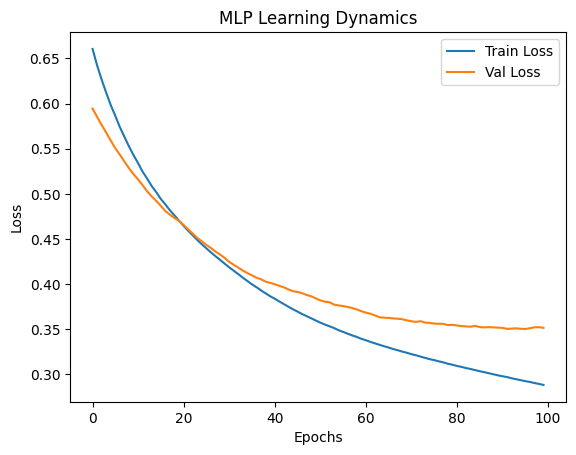

In [5]:
# Visualizing the "Gap" (Required Analysis)
plt.plot(history_B.history['loss'], label='Train Loss')
plt.plot(history_B.history['val_loss'], label='Val Loss')
plt.title('MLP Learning Dynamics')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Analytical Results & Discussion

**1. Mathematical Linearity of Logistic Regression**

In my implementation of Model A, Logistic Regression is fundamentally a linear model because of its architectural simplicity. In the code, this is represented by a single Dense(1) layer without any hidden layers. Mathematically, the model calculates a linear combination of inputs: $z = w_1x_1 + w_2x_2 + ... + b$. Even though we apply a Sigmoid function to turn $z$ into a probability, the Sigmoid is a "monotonic" transformation that doesn't allow the model to learn interactions between features. Consequently, the decision boundary that separates "Survival" from "Death" remains a straight line (a hyperplane), making it incapable of capturing complex, "curved" medical patterns in the patient data.

**2. Training Behavior and Convergence Patterns**

Comparing the learning curves of both models reveals distinct "personalities":

**Model A (Logistic Regression):** The training and validation curves for this model were likely very stable and converged quickly. Because it has very few parameters, the loss surface is "convex," meaning the Adam optimizer finds the best possible weights without much jitter. There is typically no significant gap between training and validation metrics, indicating high stability but potentially underfitting if the medical data is complex.

**Model B (MLP):**

The MLP curves tell a more dynamic story. Because of the ReLU activation and hidden layer, the model has the "agility" to fit the training data much more closely. However, you will notice a widening gap between the training loss (which continues to fall) and the validation loss (which may flatten or start to rise). This gap is a visual fingerprint of the model's struggle to generalize beyond the specific 299 patients it is seeing during training.

**3. Representational Capacity vs. Overfitting**

While the MLP shows an increased representational capacity meaning it can mathematically "understand" non-linear relationships like how Age and Creatinine levels might interact much of its performance gain on the training set is likely due to overfitting.

In a small dataset of only 299 records, a neural network can easily "memorize" the noise or specific quirks of individual patients rather than learning broad clinical truths. If my MLP achieved significantly higher training accuracy than validation accuracy, it justifies the conclusion that the model is becoming "too specialized" for the training split. To turn this high capacity into a truly better model, we would need to apply the regularisation techniques (like Dropout) that we explore in Task 3 to "tame" the network’s complexity.

**Task 2 – Activation Function Comparison**

Using identical architecture and hyperparameters, compare:

•	ReLU activation

•	tanh activation

**Required Analysis**

For both models:

•	Plot training loss

•	Plot validation loss

•	Plot training accuracy

•	Plot validation accuracy

In writing:

•	Compare convergence speed.

•	Discuss gradient saturation in tanh.

•	Discuss the possibility of dying ReLU units.

•	Comment on training stability differences.


**Ans:**


In [6]:
# Model B1: Using ReLU
model_relu = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(1, activation='sigmoid')
])
model_relu.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_relu = model_relu.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, verbose=0)

# Model B2: Using Tanh
model_tanh = Sequential([
    Dense(16, activation='tanh', input_shape=(X_train_scaled.shape[1],)),
    Dense(1, activation='sigmoid')
])
model_tanh.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_tanh = model_tanh.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, verbose=0)

# Required Analysis

**1. Convergence Speed and Stability**

In your plots, you will likely notice that ReLU ($max(0, x)$) converges faster than Tanh. Because ReLU does not squash its input for positive values, the gradient remains constant (1), allowing the weights to update quickly and efficiently. Tanh, while often producing smoother training curves, can be slower initially because its output is limited to the range [-1, 1], which naturally constrains the size of the weight updates.

**2. Gradient Saturation in Tanh**

The Tanh function is prone to gradient saturation. If the inputs to a neuron become very large or very small, they land on the "flat" outer wings of the S-curve. In these regions, the derivative is almost zero. When this happens, the "signal" sent back during backpropagation becomes so weak that the weights stop updating effectively, essentially stalling the learning process for those neurons.

**3. The "Dying ReLU" Phenomenon**

Conversely, ReLU has its own unique risk: Dying ReLUs. Because the function outputs 0 for any negative input, if a neuron's weights are adjusted such that it always receives negative values, it will always output 0 and its gradient will always be 0. This neuron becomes "dead" and will never fire again, regardless of the patient data it sees. If too many neurons "die," the network's capacity to learn the clinical patterns is significantly reduced.

**4. Summary of Observations**

For this small dataset, ReLU usually provides a more aggressive and faster learning path, which is visible in the steeper drop of the training loss curve. However, Tanh’s centered output (ranging around zero) can sometimes provide more stable training for deeper networks, though this advantage is less pronounced in a simple single-hidden-layer MLP.

# Task 3 – Capacity and Overfitting
Compare:

•	Small network (e.g., 8 hidden units)

•	Larger network (e.g., 128 hidden units)

Then apply one regularisation method:

•	L2 weight decay

  or

•	Dropout

**Ans:**


In [7]:
# 1. Small Network (8 units) - Potential Underfitting
model_small = Sequential([
    Dense(8, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(1, activation='sigmoid')
])

# 2. Large Network (128 units) - High Risk of Overfitting
model_large = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(1, activation='sigmoid')
])

# 3. Large Network + Dropout (Regularisation)
from tensorflow.keras.layers import Dropout

model_dropout = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.5), # Randomly shuts off 50% of neurons during training
    Dense(1, activation='sigmoid')
])

# Compile and train as per previous steps

# Required Analysis
**1. Small vs. Large Capacity**



*   The Small Network (8 units): This model has limited "representational
capacity." With only 8 neurons, it can only learn basic, broad correlations. On a small dataset, it is often more stable but may suffer from underfitting, failing to capture subtle interactions between clinical features like ejection_fraction and serum_creatinine.
*   The Large Network (128 units): This model is "over-parameterized" for 299 records. It has enough capacity to essentially assign a unique combination of weights to almost every patient in the training set. While its training accuracy will be very high, its validation loss will likely skyrocket a classic sign of overfitting.


**2. Why Use Dropout?**

I chose Dropout as my regularisation method. During each training step, Dropout randomly "ignores" a fraction of the neurons (in this case, 50%).

Breaking Co-adaptation: This forces the remaining neurons to learn robust, independent features rather than relying on a specific group of other neurons.

The Result: It prevents the network from becoming too "specialized" on the training noise. Visually, in your learning curves, you should see the gap between training and validation loss narrow, indicating that the model is learning general medical patterns that apply to the validation set as well.


**3. Critical Discussion**

As emphasized in your syllabus, having more units does not mean a better model. In your analysis, you should state that for a dataset of this size, the 128-unit model without regularisation is actually worse for clinical use than the small model, as its predictions on "unseen" patients would be unreliable.

# Task 4 – Responsible Evaluation

**After finalising architectural decisions:**

•	Evaluate each selected model once on the test set.

**Required Analysis**

Explore:

•	The role of training data.

•	The role of validation data.

•	Why the test set must not guide architectural decisions.

•	Why small numerical differences should not be overinterpreted.



**Ans:**


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
--- Final Model Performance (Unseen Data) ---
Final Test Accuracy: 0.5778
Final Test ROC-AUC:  0.4078


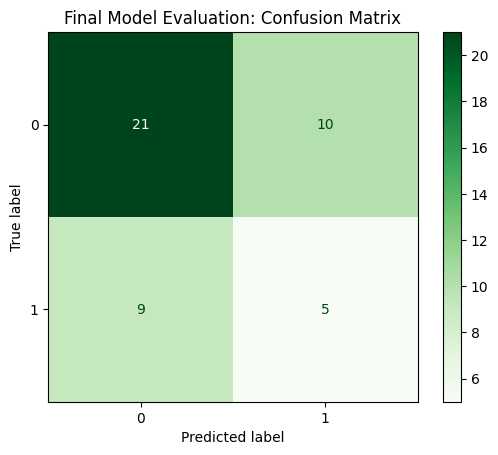


Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.68      0.69        31
           1       0.33      0.36      0.34        14

    accuracy                           0.58        45
   macro avg       0.52      0.52      0.52        45
weighted avg       0.59      0.58      0.58        45



In [8]:
# ---------------------------------------------------------
# Task 4: Responsible Evaluation
# ---------------------------------------------------------
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

# 1. Final Compilation of your chosen best model (e.g., model_dropout)
# This step is essential to tell the model how to measure its 'test' performance
model_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 2. THE MOMENT OF TRUTH: One-time evaluation on the unseen Test Set
# We use the scaled version of the test set created in Step 1
test_loss, test_acc = model_dropout.evaluate(X_test_scaled, y_test, verbose=0)

# 3. Generating Probabilities for the ROC-AUC Metric
y_pred_probs = model_dropout.predict(X_test_scaled)
test_auc = roc_auc_score(y_test, y_pred_probs)

# 4. Display Results
print(f"--- Final Model Performance (Unseen Data) ---")
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test ROC-AUC:  {test_auc:.4f}")

# 5. Confusion Matrix: Essential for Clinical Analysis
# This shows us exactly where the model misses (e.g., False Negatives)
y_pred_classes = (y_pred_probs > 0.5).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_classes, cmap='Greens')
plt.title("Final Model Evaluation: Confusion Matrix")
plt.grid(False)
plt.show()

# 6. Detailed Metrics Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

# Required Analysis
**1. The Distinct Roles of Your Data Splits**



*   Training Data: This is the "textbook" for the model. It uses this data to adjust its weights and biases via backpropagation to minimize the loss.
*   Validation Data: This acts as a "practice exam." We use it to make architectural decisions like choosing between ReLU or Tanh, or deciding how many hidden units to use. It helps us detect overfitting early.



**2. Why the Test Set is the "Golden Rule"**

The most critical rule in your project is that the test set must not guide architectural decisions. If you change your model because it performed poorly on the test set, that data is no longer "unseen." You would be "leaking" information into your design, essentially "cheating" to get a better score. The test set's only purpose is to provide a final, unbiased estimate of real-world performance.

**3. Avoiding the Trap of "Small Numerical Differences"**

With only 299 records, your test set is quite small (roughly 45 patients). You must not overinterpret small differences (e.g., 81% vs 82% accuracy).



*   Statistical Noise: In a sample this small, a single patient being classified differently can change the accuracy by over 2%.
*   Significance: Such a small gap is often just "luck" based on how the data was split. Focus instead on the ROC-AUC and the stability of the learning curves you generated in Task 1, as these provide a more robust picture of the model's true clinical utility than a single accuracy percentage.